# Instrukcja: JupyLab - środowisko do ćwiczeń

- Krzysztof Molenda, 1.09.2026

> Wersja przeglądarkowa JupyterLab, zbudowana na bazie JupyterLite. Nie wymaga instalowania czegokolwiek na lokalnym komputerze. Nie wymaga też rejestracji czy autoryzacji uzytkownika. Kod uruchamiany jest w przeglądarce, a nie na serwerze (technologia WASM). Wersja ta jest przeznaczona do ćwiczeń i nie wymaga instalacji JupyterLab ani Pythona na lokalnym komputerze.

> Wersja dostosowana jest do prowadzania ćwiczeń - wymagane pakiety zostały preinstalowane.

> Publikowane dokumenty wykorzystują MyST Markdown, który jest rozszerzeniem Markdown. W przypadku otwarcia dokumentu w innych środowiskach niektóre treści mogą być niepoprawnie wyświetlane, ale nadal powinny być czytelne, zaś kod powinien działać poprawnie.

## Wymagania

- Przeglądarka oparta o silnik Chromium 89+ (Chrome/Edge)
- Przeglądarka Firefox (nie testowane)

## Wykorzystanie

- Tworzone dokumenty przechowywane są na lokalnym komputerze (w cache'u przeglądarki). Można je pobierać na lokalny komputer (<code>Download</code>).

- *Cache* przeglądarki jest nietrwałą pamięcią, więc po zamknięciu przeglądarki i wyczyszczeniu cache'u, dokumenty zostaną utracone. Jeśli jednak cache nie zostanie wyczyszczony, dokumenty będą dostępne po ponownym uruchomieniu przeglądarki.

- Można zainstalować JupyterLite jako aplikację PWA (Progressive Web App) na komputerze. W tym celu należy:

  - Kliknąć w ikonę "Zainstaluj aplikację" w prawym górnym rogu paska adresu przeglądarki

  - Aplikacja zostanie zainstalowana na komputerze i będzie dostępna w menu startowym

  - Nadal będzie to przeglądarkowa wersja JupyterLite, ale będzie można ją uruchomić jako aplikację PWA

- Do środowiska można przesłać lokalne pliki (ikona <code>Upload</code>) i otworzyć je w JupyterLite. Pliki można również przesłać do środowiska wskazując na adres URL (menu <code>File -> Open from URL</code>) lub przeciągając i upuszczając je w obszarze menedżera plików.

- Utworzone pliki w środowisku będą przechowywane w cache'u przeglądarki do momentu jego wyczyszczenia. Z poziomu JupyterLite czyszczenie całego cache'a można wykonać klikając prawym przyciskiem myszy w obszarze plików i wybierając <code>Clear Browser Data</code> lub z menu Help wybierając <code>Clear Browser Data</code>.

  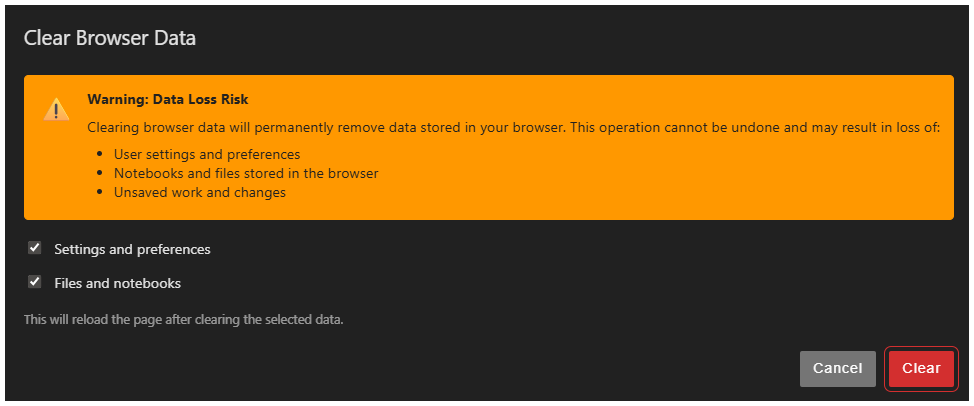

- W środowisku mogą być udostępnione różne pliki wymagane do realizacji ćwiczeń. Pliki te można modyfikować. Uruchomienie kodu będzie dotyczyło ich zmodyfikowanych wersji. Usunięcie takiego "predefiniowanego" pliku spowoduje, że jego zawartość zostanie przywrócona do stanu pierwotnego.

## Technikalia

### Kernele

To środowisko JupyterLite udostępnia trzy kernele obliczeniowe:

- xeus-python (XPython), oparty na projekcie <https://github.com/jupyter-xeus/xeus-python>
- xeus-sqlite (XSQLite), oparty na projekcie <https://github.com/jupyter-xeus/xeus-sqlite>
- Pyodide, oparty na projekcie <https://github.com/jupyterlite/pyodide-kernel>

Każdy z nich działa całkowicie w przeglądarce internetowej, bez potrzeby instalowania Pythona lub dodatkowego oprogramowania na komputerze użytkownika.

Który kernel wybrać?

#### Python 3.13 (XPython) - zalecany

Jest to podstawowy kernel przeznaczony do większości ćwiczeń realizowanych podczas zajęć.

Zalety:

- bardzo dobra zgodność ze standardowym Pythonem,
- obsługa wielu bibliotek naukowych i inżynierskich,
- możliwość korzystania z pakietu requests do pobierania danych z Internetu,
- łatwe korzystanie z bibliotek, instalacja z kanału mamba/conda
- większa wydajność niż w przypadku niektórych zastosowań Pyodide.

Przykładowe zastosowania:

- programowanie w Pythonie,
- analiza danych,
- wizualizacja danych,
- teoria grafów (NetworkX),
- symulacje,
- algebra komputerowa,
- praca z usługami sieciowymi i API.

W materiałach dydaktycznych, jeśli nie podano inaczej, należy zakładać użycie właśnie tego kernela.

#### SQLite (XSQLite)

Jest to specjalizowany kernel przeznaczony do pracy z językiem SQL.

W notebooku nie piszemy kodu Python, lecz bezpośrednio polecenia SQL, np.:

```sql
CREATE TABLE studenci(
  id INTEGER,
  nazwisko TEXT
);

INSERT INTO studenci VALUES (1, 'Nowak');

SELECT * FROM studenci;
```


Zastosowania:

- nauka SQL,
- projektowanie baz danych,
- wykonywanie zapytań,
- ćwiczenia laboratoryjne z relacyjnych baz danych.

Kernel ten jest szczególnie przydatny podczas zajęć poświęconych bazom danych, ponieważ pozwala skupić się wyłącznie na języku SQL.

#### Python (Pyodide)

Pyodide to kernel wykorzystujący interpreter Python skompilowany do technologii WebAssembly.

Jest on dostarczany jako standardowy kernel JupyterLite i pozostaje dostępny głównie ze względów kompatybilności.

Zalety:

- bardzo nowa wersja języka Python,
- szerokie wsparcie społeczności JupyterLite,
- dobra zgodność z materiałami tworzonymi dla standardowego JupyterLite,
- łatwe korzystanie z bibliotek, instalacja z kanału PyPI

Ograniczenia:

- niektóre operacje sieciowe wymagają użycia mechanizmów przeglądarki (np. fetch()),
- część przykładów wykorzystujących bibliotekę requests może działać inaczej niż w klasycznym Pythonie,
- niektóre biblioteki dostępne w XPython mogą być niedostępne lub działać odmiennie.


#### Wersja Pyhona i kernela

Sprawdzenie wersji Pythona oraz kernel wykorzystywany w załadowanym notatniku można wykonać poleceniem:

In [ ]:
import sys

print(sys.version)

if sys.version.startswith("3.14"):
    print("Kernel: Pyodide")
elif sys.version.startswith("3.13"):
    print("Kernel: Xeus")
else:
    print("Kernel: nieznany")

### Preinstalowane pakiety

W ramach środowiska zainstalowane są najczęściej używane do zajęć pakiety.

Sprawdzenie dostępnych pakietów można wykonać poleceniem:

- `%mamba list` lub `%conda list` - dla pakietów zainstalowanych przy użyciu menedżera `mamba/conda` z kanału `conda-forge`
- `%pip list` - dla pakietów zainstalowanych przy pomocy menedżera `pip` z kanału PyPI (_Python Package Index_)


W bardziej uniwersalny sposób można uruchomić kod Pythona wypisujący zainstalowane i zarejestrowane pakiety:

In [ ]:
from importlib.metadata import distributions

for dist in distributions():
    print(f"{dist.metadata['Name']}=={dist.version}")

### Instalacja nowych pakietów

Zainstalowanie dodatkowych pakietów jest możliwe w tej wersji JupyterLab (kernel Xeus) za pomocą menedżera `mamba` lub `conda` - z użyciem magicznych instrukcji JupyterLite (poprzedzonych `%`):

```
%mamba install <nazwa_pakietu>
```

Oprogramowanie pobierane będzie z oficjalnego kanału `conda-forge`, o ile występuje ich skompilowana wersja wasm WASM (_WebAssembly_). Użytkownicy raportują pewne problemy z ustalaniem zależności przez `mamba/conda` - w takiej sytuacji przed instalacją własciwego pakietu należy ręcznie wcześniej zainstalować zależne od niego inne pakiety.

Niektóre pakiety nie są dostepne w `conda-forge` - można posłużyć się repozytorium PyPI i menedżerem `pip`. W przypadku kernela Pyodide korzystamy tylko z `pip`:

```
%pip install <nazwa_pakietu>
```

lub jawnie kodem Pythona w komórce:

```python
import micropip
await micropip.install('nazwa_pakietu')
```

## Edytowanie kodu



### Autouzupełnianie kodu

W niektórych kontekstach wpisując kod możesz nacisnąć klawisz <kbd>Tab</kbd> aby zobaczyć podpowiedzi.

In [ ]:
# ustaw się na końcu kodu i wciśnij Tab aby zobaczyć dostępne opcje z modułu `sys`
from sys import 

### Inspekcja kodu

Jeśli chcesz dowiedzieć się więcej na temat określonej funkcji, możesz poprzedzić ją znakiem zapytania i uruchomić komórkę:

In [ ]:
?print

Możesz również, pisząc kod i podając nazwę funkcji, użyć kombinacji klawiszy <kbd>Shift</kbd> + <kbd>Tab</kbd>:

In [ ]:
print(

### Wprowadzanie danych z klawiatury

Standardowo, aby wczytać dane (napis) z klawiatury i zapamiętać w zmiennej, uzywamy funkcji `input`:

In [ ]:
imie = input("Podaj swoje imię: ")

In [ ]:
print("Witaj, " + imie)

## Debugowanie kodu i podgląd zmiennych

JupyterLite działa w przeglądarce i jest uproszczoną, lżejszą wersją pełnego JupyterLab. Stąd, ma wiele ograniczeń (m.in w zakresie interaktywnego debugowania kodu).

W kodzie można stosować klasyczne metody debugowania, takie jak wstawianie instrukcji `print()` w kluczowych miejscach, aby śledzić wartości zmiennych i przepływ wykonywania.

Można również korzystać z modułu `pdb` (`Python Debugger`). W JupyterLite można próbować umieścić w kodzie `import pdb; pdb.set_trace()`, choć ze względu na środowisko częściowa funkcjonalność może być ograniczona. Aby zacząć go używać, należy:

1. Zaimportować moduł pdb i wstawić w miejsce, w którym chcemy zatrzymać wykonanie kodu, komendę:

    ```python
    import pdb; pdb.set_trace()
    ```

    Spowoduje to zatrzymanie programu i wejście w interaktywny tryb debuggera.

2. W trybie debuggera możemy wykonać następujące podstawowe komendy:
    
    - `n` (next) — przejście do następnej linii kodu,
    - `s` (step) — wejście do funkcji wywoływanej w bieżącej linii,
    - `c` (continue) — kontynuacja wykonywania programu do następnego breakpointu lub końca,
    - `l` (list) — wyświetlenie kilku linijek kodu źródłowego wokół aktualnej linii,
    - `p <zmienna>` — wypisanie wartości zmiennej,
    - `q` (quit) — wyjście z trybu debuggera i zakończenie programu.

3. Można także ustawiać breakpoints przed uruchomieniem debugera, np. w kodzie:

    ```python
    pdb.set_trace()
    ```

    zatrzyma działanie i pozwoli na interaktywną inspekcję stanu programu.

4. W trybie debugowania można poruszać się po stosie wywołań (komendy `u` – up, `d` – down), sprawdzać aktualne zmienne oraz lokalizacje.

5. Aby zakończyć sesję debuggera i kontynuować, wpisuje się `c` lub aby wyjść całkowicie `q`.


```{important} WAŻNE
Do wypisania aktywnych zmiennych w notatniku służą magiczne komendy JupyterLite umieszczone w komórce kodu:

- `%who` - wypisuje listę zmiennych
- `%whos` - wypisuje zmienne i aktualne ich wartości
```


In [ ]:
x = 1
y = 2
import pdb; pdb.set_trace()
z = x + y

In [ ]:
%who

In [ ]:
%whos

## Zastrzeżenia i ostrzeżenia

%MyST

:::{warning} Zastrzeżenie
Środowisko to jest wersją eksperymentalną. Nie ma gwarancji poprawnego funkcjonowania, w szczególności trwałego przechowywania plików oraz nieoczekiwanych zmian w konfiguracji.

Po zakończeniu pracy pobierz swój notatnik na lokalny komputer!
:::